# 03 — Wi-Fi Deduplication Model

This notebook addresses **Problem 1 of the TFG** (the multi-device problem):
each student connects 1–3 devices to the network, so raw connection counts
overestimate real headcounts.

We train a Random Forest on simulator data (where ground truth is known)
that learns to map *raw connection counts* → *real number of people*.

**Input:**
- `data/raw/Conexiones_WiFi_Campus.csv` — raw simulator output

**Output:**
- `outputs/models/wifi_deduplication_rf.pkl`
- `data/interim/ocupacion_por_hora.csv` — predicted real headcounts per hour


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

DATA_RAW = Path('../data/raw')
DATA_INTERIM = Path('../data/interim')
MODELS = Path('../outputs/models')
MODELS.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42


## 1. Load and aggregate raw Wi-Fi connections to hourly counts

In [13]:
print("1. Loading raw simulator output... (may take 1-2 min)")
df = pd.read_csv(DATA_RAW / 'Conexiones_WiFi_Campus.csv', low_memory=False)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], dayfirst=True)
# Aggregate to hourly granularity
df['Hora_Truncada'] = df['Timestamp'].dt.floor('H')

print("2. Aggregating to hourly counts...")
hourly = df.groupby('Hora_Truncada').agg(
    Conexiones_WiFi=('MAC_Dispositivo', 'count'),     # raw connection count (noisy)
    Personas_Reales=('ID_Universidad',                 # GROUND TRUTH (excludes fixed devices)
                     lambda x: x[x != 'UPF_EQUIPAMIENTO'].nunique())
).reset_index()

hourly = hourly.rename(columns={'Hora_Truncada': 'Timestamp'})
print(f"Aggregated to {len(hourly):,} hourly observations.")
hourly.head()


1. Loading raw simulator output... (may take 1-2 min)


C:\Users\jordi\AppData\Local\Temp\ipykernel_20984\3013388906.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['Hora_Truncada'] = df['Timestamp'].dt.floor('H')


2. Aggregating to hourly counts...
Aggregated to 8,784 hourly observations.


,Timestamp,Conexiones_WiFi,Personas_Reales
0,2024-01-01 00:00:00,192,0
1,2024-01-01 01:00:00,256,0
2,2024-01-01 02:00:00,256,0
3,2024-01-01 03:00:00,256,0
4,2024-01-01 04:00:00,256,0


## 2. Build temporal features

In [14]:
hourly['Hora'] = hourly['Timestamp'].dt.hour
hourly['Minuto'] = hourly['Timestamp'].dt.minute  # always 0 after truncation, but kept for compatibility
hourly['Dia_Semana'] = hourly['Timestamp'].dt.dayofweek
hourly['Es_FinDeSemana'] = (hourly['Dia_Semana'] >= 5).astype(int)

features = ['Conexiones_WiFi', 'Hora', 'Minuto', 'Dia_Semana', 'Es_FinDeSemana']
target = 'Personas_Reales'

X = hourly[features]
y = hourly[target]
print(f"Features: {features}")
print(f"Target:   {target}")


Features: ['Conexiones_WiFi', 'Hora', 'Minuto', 'Dia_Semana', 'Es_FinDeSemana']
Target:   Personas_Reales


## 3. Train Random Forest

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print("Training Random Forest deduplication model...")
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

predicciones = modelo_rf.predict(X_test)
mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print(f"\n📊 Deduplication model performance:")
print(f"  MAE: {mae:.2f} people")
print(f"  R²:  {r2:.4f}")


Training Random Forest deduplication model...

📊 Deduplication model performance:
  MAE: 12.68 people
  R²:  0.9972


## 4. Generate predictions for the full dataset

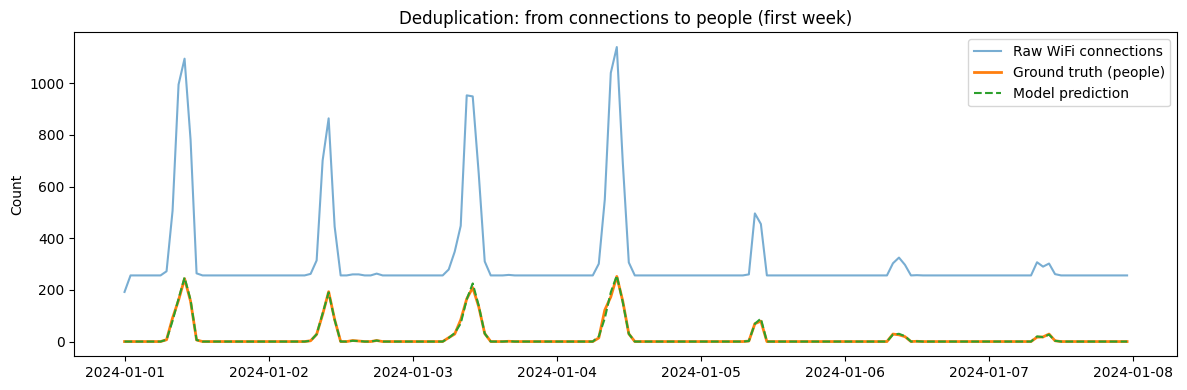

In [16]:
# Predict for ALL hours (not just test set)
hourly['Prediccion_Personas'] = modelo_rf.predict(X)
hourly['Prediccion_Personas'] = hourly['Prediccion_Personas'].round().astype(int).clip(lower=0)

# Sanity plot
fig, ax = plt.subplots(figsize=(12, 4))
sample = hourly.head(168)  # 1 week
ax.plot(sample['Timestamp'], sample['Conexiones_WiFi'], label='Raw WiFi connections', alpha=0.6)
ax.plot(sample['Timestamp'], sample['Personas_Reales'], label='Ground truth (people)', linewidth=2)
ax.plot(sample['Timestamp'], sample['Prediccion_Personas'], label='Model prediction', linestyle='--')
ax.set_title("Deduplication: from connections to people (first week)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Save model and hourly headcount table

In [17]:
# Save model + the column order it expects
joblib.dump(modelo_rf, MODELS / 'wifi_deduplication_rf.pkl')
joblib.dump(features, MODELS / 'wifi_deduplication_features.pkl')

# Save the hourly predictions for downstream merging
hourly[['Timestamp', 'Personas_Reales']].to_csv(
    DATA_INTERIM / 'ocupacion_por_hora.csv', index=False
)

print("✅ Model and hourly headcount table saved.")
print(f"   Model:    {MODELS / 'wifi_deduplication_rf.pkl'}")
print(f"   Headcounts: {DATA_INTERIM / 'ocupacion_por_hora.csv'}")


✅ Model and hourly headcount table saved.
   Model:    ..\outputs\models\wifi_deduplication_rf.pkl
   Headcounts: ..\data\interim\ocupacion_por_hora.csv
